
# Exploration du corpus KALLAAMA — Wolof

> **Objectif** — Produire un notebook propre analysant 3 audios KALLAAMA :
> chargement, parsing des transcriptions `.stm`, visualisations, écoute, synthèse.
> Exercice intégrateur du sprint fondations : NumPy, Pandas, Librosa et l'Unité 1
> du cours HF Audio se rencontrent ici sur les vraies données du projet.
>
> **Budget** — ~6 h (jeudi soir, vendredi, samedi matin)
> **Livrable** — `notebooks/01_kallaama_exploration.ipynb`, commité dans le dépôt

---

## Le corpus

**KALLAAMA** — *A Transcribed Speech Dataset about Agriculture in the Three Most
Widely Spoken Languages in Senegal* (production 2023, publication RAIL 2024).

Thématique **agriculture** : alignement direct avec Ñoo Far.

| | |
|---|---|
| **Porteur** | Jokalante (Dakar) |
| **Partenaires** | Orange Innovation (Lannion), École Polytechnique de Thiès |
| **Financement** | Lacuna Fund |
| **Langues** | wolof (`wol`), pulaar (`fuc`), sereer (`srr`) |
| **Audio** | WAV, 16 kHz, 16 bits, mono |
| **Transcriptions** | `.stm` (NIST) — **format retenu** · `.trs` (Transcriber XML) — métadonnées locuteur |
| **Licence** | CC-BY 4.0 — usage commercial, modification et redistribution autorisés, sous réserve d'attribution |

### Volumes — wolof

| Set | Fichiers | Audio | Parole annotée |
|---|---:|---:|---:|
| Whole | 153 | 55 h 11 | 51 h 08 |
| **Checked** | **36** | **12 h 49** | **11 h 47** |

Le *checked set* est un sous-ensemble vérifié manuellement du *whole set* :
mêmes audios, transcriptions relues. C'est lui qui servira de **corpus d'évaluation**
pour le baseline WER.

In [4]:
import numpy as np
from pathlib import Path
import pandas as pd
import re
from collections import Counter
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio, display


In [42]:
PROJECT_ROOT = Path(r"C:\dev\noo-far-pipeline")
CORPUS_DIR   = PROJECT_ROOT / "data" / "kallaama" / "wolof" / "speech_dataset"
CHECKED_DIR  = CORPUS_DIR / "checked_transcriptions"

## 1. Inventaire des fichiers

Comptage des trois formats présents dans l'arborescence du corpus.

In [14]:
corpus_dir = Path("../data/kallaama/wolof/speech_dataset")
wav_files = list(corpus_dir.glob("**/*.wav"))
trs_files = list(corpus_dir.glob("**/*.trs")) 
stm_files = list(corpus_dir.glob("**/*.stm"))
audio_map = {p.stem: p for p in wav_files}

print(f'Nombre de .wav : {len(wav_files)}')
print(f'Nombre de .trs : {len(trs_files)}')
print(f'Nombre de .stm : {len(stm_files)}')

Nombre de .wav : 153
Nombre de .trs : 189
Nombre de .stm : 189


In [39]:
checked_dir = Path("../data/kallaama/wolof/speech_dataset/checked_transcriptions")
print(checked_dir.exists(), len(list(checked_dir.rglob("*.stm"))))

True 36


### Résultats

| Format | Nombre | Rôle |
|---|---|---|
| `.wav` | 153 | Audio source, 16 kHz |
| `.stm` | 189 | Annotations, format d'évaluation NIST |
| `.trs` | 189 | Annotations Transcriber (XML), métadonnées locuteur |

**Écart 189 / 153** : les 36 fichiers supplémentaires correspondent au *checked set*
(transcriptions vérifiées manuellement), stockées dans un dossier distinct.

## 2. Durées des enregistrements

Lecture des en-têtes WAV via `librosa.get_duration` (pas de décodage complet).

<Axes: >

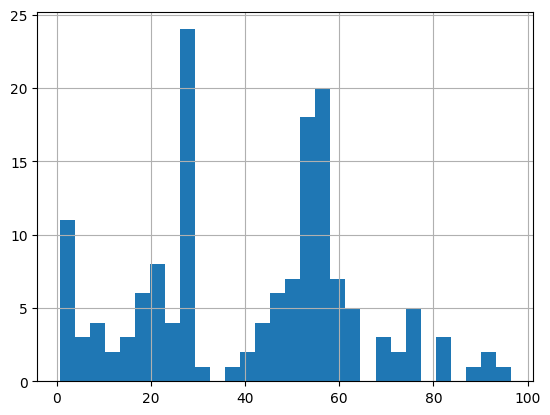

In [3]:
df = pd.DataFrame({"path": wav_files})
df["name"] = df["path"].apply(lambda p: p.stem)
df["size_mb"] = df["path"].apply(lambda p: p.stat().st_size / 1e6)
df.describe()
df["size_mb"].hist(bins=30)

In [4]:
durees = [librosa.get_duration(path=str(w)) for w in wav_files]
print(f"total  : {sum(durees)/3600:.2f} h")
print(f"médiane: {np.median(durees)/60:.1f} min")
print(f"min/max: {min(durees):.1f}s / {max(durees)/60:.1f} min")

c:\Users\Pro\miniconda3\envs\noofar\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


total  : 55.19 h
médiane: 25.0 min
min/max: 20.9s / 50.2 min


In [46]:
total = Counter()
for f in CHECKED_DIR.rglob("*.stm"):
    _, stats = parse_stm(f)
    total.update(stats)

for k, v in total.items():
    print(f"{k:20s} : {v:6d}")

lignes_lues          :  13061
segments_retenus     :  11098
rejet_sans_texte     :    465
rejet_exclus         :   1484
rejet_bornes         :     14


### Résultats

- **Total** : 55,19 h
- **Médiane** : 25,0 min
- **Min / Max** : 20,9 s / 50,2 min

**Implication pour le pipeline** : les enregistrements sont longs (médiane 25 min),
bien au-delà de la fenêtre de 30 s de Whisper. L'unité de traitement ne sera donc
pas le fichier mais le **segment**, défini par les bornes temporelles des `.stm`.

## 3. Fonction de parsing .stm

[code] Définition parse_stm + test

In [45]:
def parse_stm (stm_path, encoding = "utf-8") :
    '''Parse le fichier stm et renvoie une liste de segments 
    ainsi que des statistiques sur le fichier'''

    segments = []
    statistiques = {
    "lignes_lues": 0,
    "segments_retenus": 0,
    "rejet_sans_texte": 0,
    "rejet_exclus": 0,
    "rejet_bornes": 0,
}

    with open(stm_path, encoding=encoding) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith(';;'): 
                continue
            statistiques["lignes_lues"]+=1
            
            parts = line.split(maxsplit=6)

            # --- REJET 1 : ligne sans texte (6 champs) ---
            if len(parts) < 7 :
                statistiques["rejet_sans_texte"]+=1
                continue

            # --- REJET 2 : zone exclue du scoring ---
            if parts [2] == "excluded_region":
                statistiques["rejet_exclus"]+=1
                continue

            # --- REJET 3 : bornes dégénérées ---
            a = float(parts[3])
            b = float(parts[4])
            if b <= a :
                statistiques["rejet_bornes"]+=1
                continue 

            #--- La ligne est un segment de parole ---
            segments.append({
                "file": parts[0],
                "channel": parts[1],
                "speaker": parts[2],
                "start": float(parts[3]),
                "end": float(parts[4]),
                "label": parts[5],
                "text": parts[6],
            })
            statistiques["segments_retenus"]+=1

    return (segments,statistiques)


In [6]:
def parse_label(label):
    parts = label.strip('<>').split(',')
    return {
        "canal": parts[0] if len(parts) > 0 else "",
        "condition": parts[1] if len(parts) > 1 else "",
        "genre": parts[2] if len(parts) > 2 and parts[2] else "unknown",
    }

In [ ]:
def clean_text_for_wer(text, strip_disfluencies=True, strip_lang_tags=True,
                       strip_brackets=True, lowercase=True, strip_punct=True):
 

    # --- 1. CROCHETS : événements acoustiques ---------------------------
    if strip_brackets:
        text = re.sub(r'\[[^\]]*\]', ' ', text)

    # --- 2. TAGS DE LANGUE : code-switching ------------------------------
    if strip_lang_tags:
        text = re.sub(r'\s*:\s*[A-Za-z]{2,4}\b', '', text)

    # --- 3. DISFLUENCES ---------------------------------------------------
    if strip_disfluencies:
        text = re.sub(r'\s*%+\S+\s*', ' ', text)

    # --- 4. CASE ---------------------------------------------------------
    if lowercase:
        text = text.lower()

    # --- 5. PONCTUATION ---------------------------------------------------
    if strip_punct:
        text = re.sub(r"[^\w\sàâäéèêëîïôöùûüÿçñ']", ' ', text)

    # --- 6. NORMALISATION FINALE ------------------------------------------
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [8]:
segments = parse_stm("../data/kallaama/wolof/speech_dataset/checked_transcriptions/14/stm_format/wol_11450.stm")
print(f"Nombre de segments : {len(segments)}")

# Décompte par genre (utile pour l'analyse de biais)
genres = Counter("female" if "female" in s["label"] else "male" for s in segments)
print(f"Genres : {dict(genres)}")

# Aperçu de segments avec nettoyage
for seg in segments[:5]:
    clean = clean_text_for_wer(seg["text"])
    print(f"[{seg['start']:.1f}s → {seg['end']:.1f}s | {seg['speaker']}]")
    print(f"  Brut    : {seg['text']}")
    print(f"  Nettoyé : {clean}")

Nombre de segments : 2
Genres : {'male': 2}
[0.0s → 50.5s | locuteur_1]
  Brut    : asalaamaaleykum mbokku baykat yi man la Bada Mbengue nekk saytukatu coopérative :fra agricole :fra bu Kell Guèye [r] nekk Nangour Ndiaye waa Mbeejéen gën koo xamee ci Pader waa Cepp gën koo xamee ci Nangour kuréel googu nag moo dellu si di leen xamal ne am na ay semence :fra certifiée :fra [r] mooy ñebe gerte ak matériels :fra agricoles :fra am nañ tamit ay pexe yoo xamente ne mën nañu ko nas ngir financé :fra leen seen campagne :fra bi [r] képp koo xamen ne sii ne bëgg nga ci sercices :fra yi ñu wax nii te nga nekk membre :fra mën ngaa woote mën ngaa bipé :fra ci 33 869 19 23 loolu du la dikkee dara ñoo ngi leen di gërëm di leen sant jërë ngeen jëf wa salaam
  Nettoyé : asalaamaaleykum mbokku baykat yi man la bada mbengue nekk saytukatu coopérative agricole bu kell guèye nekk nangour ndiaye waa mbeejéen gën koo xamee ci pader waa cepp gën koo xamee ci nangour kuréel googu nag moo dellu si di leen xamal

In [10]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 1 — INVENTAIRE AVANT NETTOYAGE
# ══════════════════════════════════════════════════════════════════════
# Objectif : savoir ce que le corpus contient RÉELLEMENT comme marqueurs
# d'annotation. Inspecter deux segments à la main ne prouve rien : les
# conventions d'annotateurs varient (majuscules, espaces, coquilles), et
# c'est précisément dans ces variations que les regex naïves échouent.

marqueurs = Counter()
# Counter = dict spécialisé qui compte les occurrences.
# .update(liste) incrémente les compteurs de chaque élément de la liste.

for f in checked_dir.rglob("*.stm"):
    # rglob = glob RÉCURSIF. Indispensable ici : les .stm sont enfouis
    # dans checked_transcriptions/<id>/stm_format/. Un glob simple
    # ne verrait rien et renverrait silencieusement une liste vide.

    for s in parse_stm(f):
        # parse_stm retourne une liste de dicts : start, end, speaker,
        # label, text. On boucle sur les segments, pas sur les fichiers.

        marqueurs.update(re.findall(r'\[[^\]]*\]|%\S+|:\s*\w+', s["text"]))
        #                                                        ^^^^^^^^^
        # TEXTE BRUT, non nettoyé. C'est le point de mesure « avant ».
        #
        # La regex est une ALTERNATIVE à trois branches (séparées par |) :
        #   \[[^\]]*\]  → crochets : [r], [rire], [musique]...
        #   %\S+        → disfluences : %hum, %e...
        #   :\s*\w+     → tags de langue : :fra, : Fra...
        #
        # Elle est volontairement LARGE : on cherche à découvrir, pas à
        # filtrer. Elle attrape même ce qu'on n'avait pas anticipé.

print(marqueurs.most_common(30))
# most_common(30) trie par fréquence décroissante. Les gros volumes en
# tête montrent où se joue l'impact ; la queue révèle les coquilles
# (:frabi, %%hum) qui feront échouer une regex trop stricte.


[(':fra', 18573), ('%hum', 7564), ('%e', 3287), ('[r]', 1200), ('[b]', 431), ('[i]', 329), ('[bb]', 183), (':Fra', 163), ('[rire]', 151), ('[mic]', 146), ('[musique]', 81), (':en', 62), ('[shh]', 45), (':ar', 43), ('[conv]', 21), ('[tx]', 20), ('[pf]', 17), ('[n]', 16), (':fa', 14), (': fra', 9), (': Fra', 7), (':an', 6), (':fr', 5), (':fre', 3), ('[i-]', 3), ('[-i]', 3), (':frabi', 2), (':ra', 2), ('%%hum', 2), (':ang', 2)]


In [11]:

# ══════════════════════════════════════════════════════════════════════
# CELLULE 2 — VÉRIFICATION APRÈS NETTOYAGE
# ══════════════════════════════════════════════════════════════════════
# Objectif : prouver que clean_text_for_wer() couvre bien TOUT l'inventaire.
# Sans ce contrôle, on ne sait pas si la fonction marche — on l'espère.
# C'est la différence entre une convention documentée et une convention
# supposée.

restants = Counter()

for f in checked_dir.rglob("*.stm"):
    for s in parse_stm(f):

        propre = clean_text_for_wer(s["text"])
        # ← LA SEULE DIFFÉRENCE avec la cellule 1.
        # On applique le nettoyage AVANT de chercher les marqueurs.
        # Oublier cet appel (erreur commise plus tôt) redonne exactement
        # les chiffres de la cellule 1 — d'où l'illusion que la fonction
        # ne marche pas, alors qu'elle n'était simplement pas appelée.

        restants.update(re.findall(r'\[[^\]]*\]|%\S+|:\s*\w+', propre))
        # MÊME REGEX que cellule 1. C'est essentiel : on mesure avec le
        # même instrument avant et après, sinon la comparaison n'a pas
        # de sens.

print("total restants :", sum(restants.values()))
# sum() sur les VALEURS du Counter = nombre total de marqueurs survivants.
# ATTENTION : sum() d'un Counter vide renvoie 0 sans broncher — comme
# most_common() renvoie []. Un résultat nul peut donc signifier « succès »
# OU « la boucle n'a rien parcouru ». Vérifier que checked_dir.exists()
# et que len(list(rglob)) == 36 AVANT de se réjouir.

print(restants.most_common())
# Objectif : liste vide (ou uniquement les cas laissés volontairement,
# comme :frabi). Tout autre marqueur = un cas que l'inventaire initial
# n'avait pas révélé, ou une regex de nettoyage trop étroite.

total restants : 0
[]


In [40]:
def extract_segment(audio, sr, start, end):
    """Retourne l'array audio correspondant au segment [start, end] en secondes."""
    return audio[int(start * sr):int(end * sr)]

 ### Résultats


## 4. Analyse détailllée des 3 audios


### Audio 1

In [15]:
# Chargement des fichiers 
audio_path = "../data/kallaama/wolof/speech_dataset/14/wol_11450.wav"
stm_path = "../data/kallaama/wolof/speech_dataset/checked_transcriptions/14/stm_format/wol_11450.stm"

audio, sr = librosa.load(audio_path, sr=16000, mono=True)
duree = len(audio) / sr
print(f"Fichier : {Path(audio_path).name}")
print(f"Durée : {duree:.1f}s | Sample rate : {sr} Hz | Canaux : mono")

Fichier : wol_11450.wav
Durée : 57.2s | Sample rate : 16000 Hz | Canaux : mono


In [16]:
# ══════════════════════════════════════════════════════════════════════
# SEGMENTS — parsing .stm, enrichissement, contrôles
# ══════════════════════════════════════════════════════════════════════

segments = parse_stm(stm_path)
df_seg = pd.DataFrame(segments)
# Le DataFrame donne accès au tri, filtrage, groupby — indispensable dès
# qu'on passe du fichier unique au corpus entier.

# --- Colonnes dérivées -------------------------------------------------

df_seg["duration"] = df_seg["end"] - df_seg["start"]

df_seg["text_clean"] = df_seg["text"].apply(clean_text_for_wer)

df_seg["gender"] = df_seg["label"].apply(lambda l: parse_label(l)["genre"])
# parse_label() et NON le test « female in l else male ».
# Sur le checked set complet : 9377 male / 1530 female / 1684 unknown.
# Le test naïf rangerait les 1684 unknown en « male » → 87,8 % masculin
# annoncé au lieu de 86 %. Sur un corpus dont on veut précisément
# DOCUMENTER le biais de genre, fabriquer le chiffre est disqualifiant.

df_seg["is_empty"] = df_seg["text_clean"].str.strip() == ""
# CRUCIAL : 30 % des segments du checked set (3784/12596) ne contiennent
# que des marqueurs (%hum %hum : 3409 occurrences) → tour de parole
# non-verbal, backchannel de l'interlocuteur.
# Ils doivent sortir de l'évaluation (référence vide = WER indéfini)
# ET du fine-tuning (apprendre au modèle à produire du vide le dégrade).

df_seg["has_codeswitch"] = df_seg["text"].str.contains(
    r':\s*[A-Za-z]{2,4}\b', regex=True
)
# [A-Za-z] et non [a-z] → capture :Fra (170 occurrences ratées sinon).
# {2,4} → couvre :en, :fra, :fre, :ang.
# Même regex que clean_text_for_wer() : les deux doivent rester alignées,
# sinon on nettoie ce qu'on ne détecte pas (ou l'inverse).

# --- Contrôles ---------------------------------------------------------

n_vides = df_seg["is_empty"].sum()
utiles = df_seg.loc[~df_seg["is_empty"]]

print(f"Segments        : {len(df_seg)}  ({n_vides} vides, {len(utiles)} utiles)")

print(f"Durée médiane   : {utiles['duration'].median():.1f}s")
print(f"  p25 / p75     : {utiles['duration'].quantile(.25):.1f}s / "
      f"{utiles['duration'].quantile(.75):.1f}s")
print(f"  min / max     : {utiles['duration'].min():.1f}s / "
      f"{utiles['duration'].max():.1f}s")
# MÉDIANE et non moyenne. La distribution est très asymétrique :
# médiane 1,4 s mais des segments >30 s. Une moyenne serait tirée par
# la queue et ne décrirait aucun segment réel.
# Les quartiles disent la dispersion ; le min/max débusque les anomalies
# (un 0.0s = timestamp corrompu, à écarter avant de nourrir Whisper).
#
# Calculé sur les segments UTILES : inclure les 3784 vides (~0,5 s chacun)
# écraserait la médiane vers le bas et décrirait le backchannel,
# pas la parole.

print(f"Locuteurs       : {df_seg['speaker'].unique().tolist()}")
print(f"Genres          : {df_seg['gender'].value_counts().to_dict()}")

print(f"Code-switching  : {df_seg['has_codeswitch'].sum()}/{len(df_seg)} "
      f"({100 * df_seg['has_codeswitch'].mean():.0f} %)")
# ~18 500 tags :fra sur ~12 600 segments : le code-switching est massif.
# C'est une caractéristique structurante du corpus, pas un détail —
# Whisper devra transcrire du français inséré dans du wolof.

df_seg.head()

Segments        : 2  (0 vides, 2 utiles)
Durée médiane   : 28.6s
  p25 / p75     : 17.6s / 39.5s
  min / max     : 6.7s / 50.5s
Locuteurs       : ['locuteur_1']
Genres          : {'male': 2}
Code-switching  : 1/2 (50 %)


,file,channel,speaker,start,end,label,text,duration,text_clean,gender,is_empty,has_codeswitch
0,wol_11450,1,locuteur_1,0.000,50.503,"<o,f1,male>",asalaamaaleykum mbokku baykat yi man la Bada M...,50.503,asalaamaaleykum mbokku baykat yi man la bada m...,male,False,True
1,wol_11450,1,locuteur_1,50.503,57.156,"<o,f1,male>",nganaaw loolu sunuy ndaw dinan leen woo gën a ...,6.653,nganaaw loolu sunuy ndaw dinan leen woo gën a ...,male,False,False


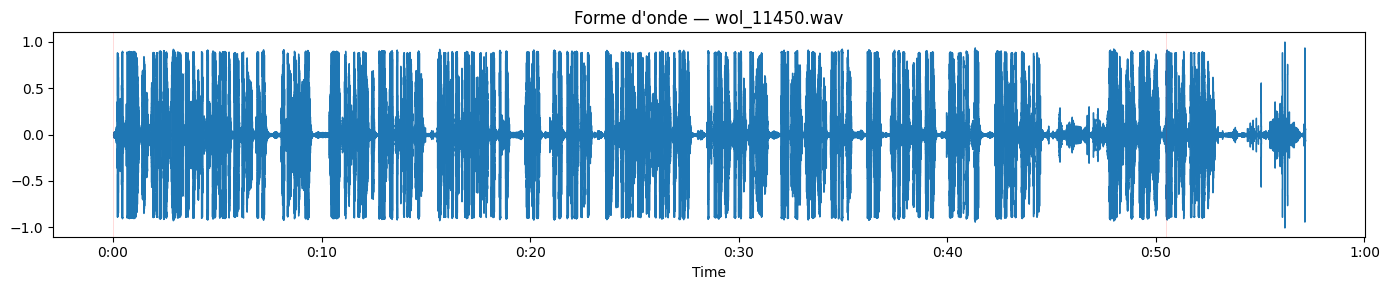

In [17]:
# Forme d'onde complète
plt.figure(figsize=(14, 3))
librosa.display.waveshow(audio, sr=sr)
plt.title(f"Forme d'onde — {Path(audio_path).name}")
# Bonus : superposer les frontières de segments
for start in df_seg["start"]:
    plt.axvline(start, color='red', alpha=0.2, linewidth=0.5)
plt.tight_layout()
plt.show()

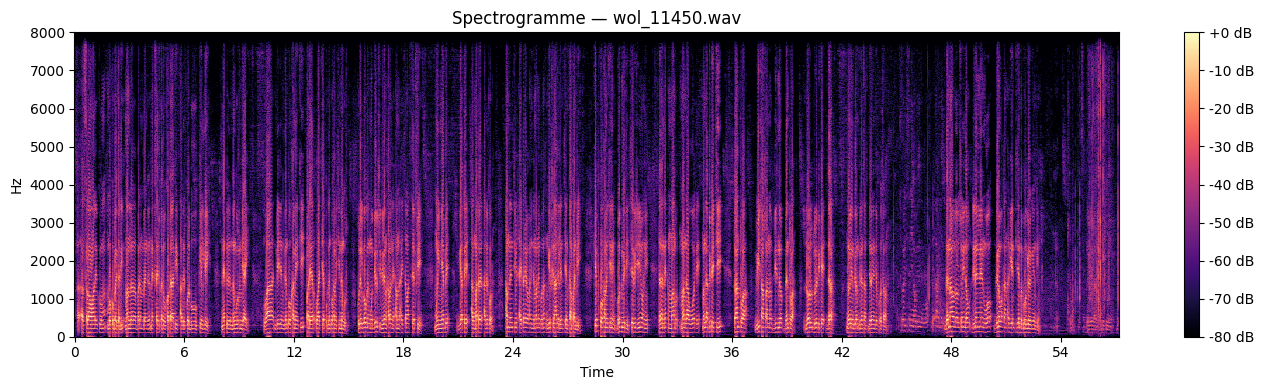

In [ ]:
# Spectrogramme complet
D = librosa.stft(audio)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure(figsize=(14, 4))
librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="hz")
plt.colorbar(format="%+2.0f dB")
plt.title(f"Spectrogramme — {Path(audio_path).name}")
plt.tight_layout()
plt.show()

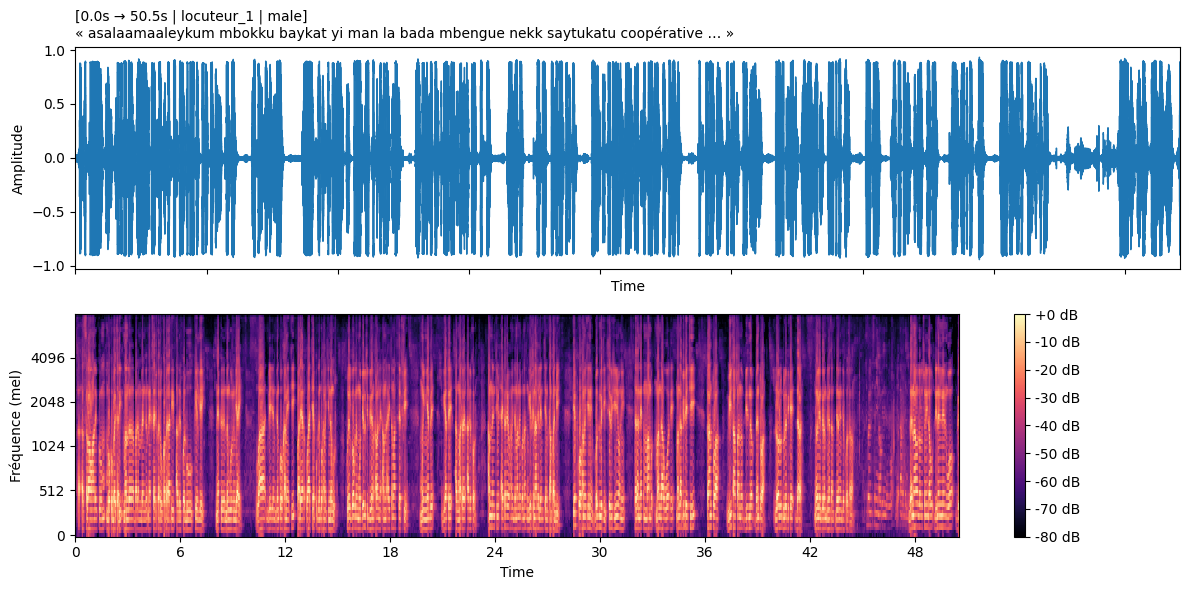

In [ ]:
seg = segments[0]
clip = extract_segment(audio, sr, seg["start"], seg["end"])

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# --- Forme d'onde ------------------------------------------------------
librosa.display.waveshow(clip, sr=sr, ax=axes[0])

titre = clean_text_for_wer(seg["text"])[:80]
axes[0].set_title(
    f"[{seg['start']:.1f}s → {seg['end']:.1f}s | {seg['speaker']} | "
    f"{parse_label(seg['label'])['genre']}]\n« {titre}… »",
    loc="left", fontsize=10
)
# Le texte brut fait ~700 caractères sur ce fichier : tronqué à 80,
# et nettoyé pour ne pas afficher les marqueurs %hum / :fra / [r].
axes[0].set_ylabel("Amplitude")

# --- Mel-spectrogramme --------------------------------------------------
S_mel = librosa.feature.melspectrogram(y=clip, sr=sr, n_mels=80)
S_db = librosa.power_to_db(S_mel, ref=np.max)

img = librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[1])
fig.colorbar(img, ax=axes[1], format="%+2.0f dB")
# n_mels=80 : ce n'est PAS arbitraire — c'est exactement l'entrée
# qu'attend Whisper (input_features). Tu visualises donc littéralement
# ce que le modèle « voit », pas une représentation décorative.
#
# Échelle mel plutôt que hz : la parole vit entre 100 Hz et 4 kHz.
# Une échelle linéaire donnerait autant de place aux 6-8 kHz (vides)
# qu'aux basses fréquences (denses en information phonétique).
axes[1].set_ylabel("Fréquence (mel)")

plt.tight_layout()
plt.show()

In [ ]:
# --- Écoute -------------------------------------------------------------
display(Audio(clip, rate=sr))
print("Référence nettoyée :", clean_text_for_wer(seg["text"]))

Référence nettoyée : asalaamaaleykum mbokku baykat yi man la bada mbengue nekk saytukatu coopérative agricole bu kell guèye nekk nangour ndiaye waa mbeejéen gën koo xamee ci pader waa cepp gën koo xamee ci nangour kuréel googu nag moo dellu si di leen xamal ne am na ay semence certifiée mooy ñebe gerte ak matériels agricoles am nañ tamit ay pexe yoo xamente ne mën nañu ko nas ngir financé leen seen campagne bi képp koo xamen ne sii ne bëgg nga ci sercices yi ñu wax nii te nga nekk membre mën ngaa woote mën ngaa bipé ci 33 869 19 23 loolu du la dikkee dara ñoo ngi leen di gërëm di leen sant jërë ngeen jëf wa salaam


### Audio 2

In [ ]:
# Chargement des fichiers 
audio_path = "../data/kallaama/wolof/speech_dataset/14/wol_11480.wav"
stm_path = "../data/kallaama/wolof/speech_dataset/checked_transcriptions/14/stm_format/wol_11480.stm"

audio, sr = librosa.load(audio_path, sr=16000, mono=True)
duree = len(audio) / sr
print(f"Fichier : {Path(audio_path).name}")
print(f"Durée : {duree:.1f}s | Sample rate : {sr} Hz | Canaux : mono")

Fichier : wol_11480.wav
Durée : 45.4s | Sample rate : 16000 Hz | Canaux : mono


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# SEGMENTS — parsing .stm, enrichissement, contrôles
# ══════════════════════════════════════════════════════════════════════

segments = parse_stm(stm_path)
df_seg = pd.DataFrame(segments)
# Le DataFrame donne accès au tri, filtrage, groupby — indispensable dès
# qu'on passe du fichier unique au corpus entier.

# --- Colonnes dérivées -------------------------------------------------

df_seg["duration"] = df_seg["end"] - df_seg["start"]

df_seg["text_clean"] = df_seg["text"].apply(clean_text_for_wer)

df_seg["gender"] = df_seg["label"].apply(lambda l: parse_label(l)["genre"])
# parse_label() et NON le test « female in l else male ».
# Sur le checked set complet : 9377 male / 1530 female / 1684 unknown.
# Le test naïf rangerait les 1684 unknown en « male » → 87,8 % masculin
# annoncé au lieu de 86 %. Sur un corpus dont on veut précisément
# DOCUMENTER le biais de genre, fabriquer le chiffre est disqualifiant.

df_seg["is_empty"] = df_seg["text_clean"].str.strip() == ""
# CRUCIAL : 30 % des segments du checked set (3784/12596) ne contiennent
# que des marqueurs (%hum %hum : 3409 occurrences) → tour de parole
# non-verbal, backchannel de l'interlocuteur.
# Ils doivent sortir de l'évaluation (référence vide = WER indéfini)
# ET du fine-tuning (apprendre au modèle à produire du vide le dégrade).

df_seg["has_codeswitch"] = df_seg["text"].str.contains(
    r':\s*[A-Za-z]{2,4}\b', regex=True
)
# [A-Za-z] et non [a-z] → capture :Fra (170 occurrences ratées sinon).
# {2,4} → couvre :en, :fra, :fre, :ang.
# Même regex que clean_text_for_wer() : les deux doivent rester alignées,
# sinon on nettoie ce qu'on ne détecte pas (ou l'inverse).

# --- Contrôles ---------------------------------------------------------

n_vides = df_seg["is_empty"].sum()
utiles = df_seg.loc[~df_seg["is_empty"]]

print(f"Segments        : {len(df_seg)}  ({n_vides} vides, {len(utiles)} utiles)")

print(f"Durée médiane   : {utiles['duration'].median():.1f}s")
print(f"  p25 / p75     : {utiles['duration'].quantile(.25):.1f}s / "
      f"{utiles['duration'].quantile(.75):.1f}s")
print(f"  min / max     : {utiles['duration'].min():.1f}s / "
      f"{utiles['duration'].max():.1f}s")
# MÉDIANE et non moyenne. La distribution est très asymétrique :
# médiane 1,4 s mais des segments >30 s. Une moyenne serait tirée par
# la queue et ne décrirait aucun segment réel.
# Les quartiles disent la dispersion ; le min/max débusque les anomalies
# (un 0.0s = timestamp corrompu, à écarter avant de nourrir Whisper).
#
# Calculé sur les segments UTILES : inclure les 3784 vides (~0,5 s chacun)
# écraserait la médiane vers le bas et décrirait le backchannel,
# pas la parole.

print(f"Locuteurs       : {df_seg['speaker'].unique().tolist()}")
print(f"Genres          : {df_seg['gender'].value_counts().to_dict()}")

print(f"Code-switching  : {df_seg['has_codeswitch'].sum()}/{len(df_seg)} "
      f"({100 * df_seg['has_codeswitch'].mean():.0f} %)")
# ~18 500 tags :fra sur ~12 600 segments : le code-switching est massif.
# C'est une caractéristique structurante du corpus, pas un détail —
# Whisper devra transcrire du français inséré dans du wolof.

df_seg.head()

Segments        : 1  (0 vides, 1 utiles)
Durée médiane   : 45.4s
  p25 / p75     : 45.4s / 45.4s
  min / max     : 45.4s / 45.4s
Locuteurs       : ['inter_segment_gap']
Genres          : {'unknown': 1}
Code-switching  : 1/1 (100 %)


,file,channel,speaker,start,end,label,text,duration,text_clean,gender,is_empty,has_codeswitch
0,wol_11480,1,inter_segment_gap,0.0,45.412,"<o,f0,>",asalaamaaleykum mbokk yi nga denc sa xaalis ya...,45.412,asalaamaaleykum mbokk yi nga denc sa xaalis ya...,unknown,False,True


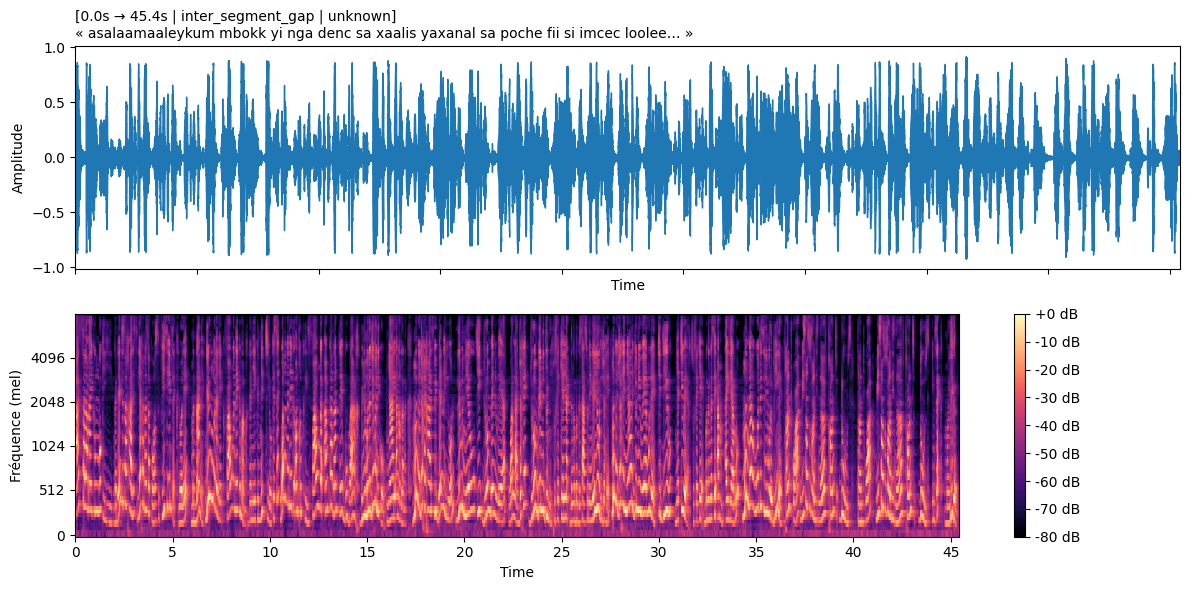

In [ ]:
seg = segments[0]
clip = extract_segment(audio, sr, seg["start"], seg["end"])

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# --- Forme d'onde ------------------------------------------------------
librosa.display.waveshow(clip, sr=sr, ax=axes[0])

titre = clean_text_for_wer(seg["text"])[:80]
axes[0].set_title(
    f"[{seg['start']:.1f}s → {seg['end']:.1f}s | {seg['speaker']} | "
    f"{parse_label(seg['label'])['genre']}]\n« {titre}… »",
    loc="left", fontsize=10
)
# Le texte brut fait ~700 caractères sur ce fichier : tronqué à 80,
# et nettoyé pour ne pas afficher les marqueurs %hum / :fra / [r].
axes[0].set_ylabel("Amplitude")

# --- Mel-spectrogramme --------------------------------------------------
S_mel = librosa.feature.melspectrogram(y=clip, sr=sr, n_mels=80)
S_db = librosa.power_to_db(S_mel, ref=np.max)

img = librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[1])
fig.colorbar(img, ax=axes[1], format="%+2.0f dB")
# n_mels=80 : ce n'est PAS arbitraire — c'est exactement l'entrée
# qu'attend Whisper (input_features). Tu visualises donc littéralement
# ce que le modèle « voit », pas une représentation décorative. 
#
# Échelle mel plutôt que hz : la parole vit entre 100 Hz et 4 kHz.
# Une échelle linéaire donnerait autant de place aux 6-8 kHz (vides)
# qu'aux basses fréquences (denses en information phonétique).
axes[1].set_ylabel("Fréquence (mel)")

plt.tight_layout()
plt.show()

In [ ]:
# --- Écoute -------------------------------------------------------------
display(Audio(clip, rate=sr))
print("Référence nettoyée :", clean_text_for_wer(seg["text"]))

Référence nettoyée : asalaamaaleykum mbokk yi nga denc sa xaalis yaxanal sa poche fii si imcec loolee mën naa ne ngir mu mën a nekk fàww nga nekk membre nga nekk nit yow kese wala nga nekk entreprise fàww nga am carte d' identité bu baax bu ñu mën a jëfandikoo ñaari anam la nag mën nga joxe xaalis bi benn yoon lu mu néew ci juróom benni weer war ngaa joxe juróom benni junni su fekkee nag da nga bëgg saa su ne ngay ñëw di joxe mën nga joxe ñaari junni weer wu ne ci diiru ñetti weer su fekkeee bëgg nga see am ay leerlu mën ngaa woote si numéro biile 33 879 30 1233 879 30 12 imcec mooy li gën


### Audio 3

In [19]:
# Chargement des fichiers 
audio_path = "../data/kallaama/wolof/speech_dataset/14/wol_11490.wav"
stm_path = "../data/kallaama/wolof/speech_dataset/checked_transcriptions/14/stm_format/wol_11490.stm"

audio, sr = librosa.load(audio_path, sr=16000, mono=True)
duree = len(audio) / sr
print(f"Fichier : {Path(audio_path).name}")
print(f"Durée : {duree:.1f}s | Sample rate : {sr} Hz | Canaux : mono")

Fichier : wol_11490.wav
Durée : 31.7s | Sample rate : 16000 Hz | Canaux : mono


In [20]:
# ══════════════════════════════════════════════════════════════════════
# SEGMENTS — parsing .stm, enrichissement, contrôles
# ══════════════════════════════════════════════════════════════════════

segments = parse_stm(stm_path)
df_seg = pd.DataFrame(segments)
# Le DataFrame donne accès au tri, filtrage, groupby — indispensable dès
# qu'on passe du fichier unique au corpus entier.

# --- Colonnes dérivées -------------------------------------------------

df_seg["duration"] = df_seg["end"] - df_seg["start"]

df_seg["text_clean"] = df_seg["text"].apply(clean_text_for_wer)

df_seg["gender"] = df_seg["label"].apply(lambda l: parse_label(l)["genre"])
# parse_label() et NON le test « female in l else male ».
# Sur le checked set complet : 9377 male / 1530 female / 1684 unknown.
# Le test naïf rangerait les 1684 unknown en « male » → 87,8 % masculin
# annoncé au lieu de 86 %. Sur un corpus dont on veut précisément
# DOCUMENTER le biais de genre, fabriquer le chiffre est disqualifiant.

df_seg["is_empty"] = df_seg["text_clean"].str.strip() == ""
# CRUCIAL : 30 % des segments du checked set (3784/12596) ne contiennent
# que des marqueurs (%hum %hum : 3409 occurrences) → tour de parole
# non-verbal, backchannel de l'interlocuteur.
# Ils doivent sortir de l'évaluation (référence vide = WER indéfini)
# ET du fine-tuning (apprendre au modèle à produire du vide le dégrade).

df_seg["has_codeswitch"] = df_seg["text"].str.contains(
    r':\s*[A-Za-z]{2,4}\b', regex=True
)
# [A-Za-z] et non [a-z] → capture :Fra (170 occurrences ratées sinon).
# {2,4} → couvre :en, :fra, :fre, :ang.
# Même regex que clean_text_for_wer() : les deux doivent rester alignées,
# sinon on nettoie ce qu'on ne détecte pas (ou l'inverse).

# --- Contrôles ---------------------------------------------------------

n_vides = df_seg["is_empty"].sum()
utiles = df_seg.loc[~df_seg["is_empty"]]

print(f"Segments        : {len(df_seg)}  ({n_vides} vides, {len(utiles)} utiles)")

print(f"Durée médiane   : {utiles['duration'].median():.1f}s")
print(f"  p25 / p75     : {utiles['duration'].quantile(.25):.1f}s / "
      f"{utiles['duration'].quantile(.75):.1f}s")
print(f"  min / max     : {utiles['duration'].min():.1f}s / "
      f"{utiles['duration'].max():.1f}s")
# MÉDIANE et non moyenne. La distribution est très asymétrique :
# médiane 1,4 s mais des segments >30 s. Une moyenne serait tirée par
# la queue et ne décrirait aucun segment réel.
# Les quartiles disent la dispersion ; le min/max débusque les anomalies
# (un 0.0s = timestamp corrompu, à écarter avant de nourrir Whisper).
#
# Calculé sur les segments UTILES : inclure les 3784 vides (~0,5 s chacun)
# écraserait la médiane vers le bas et décrirait le backchannel,
# pas la parole.

print(f"Locuteurs       : {df_seg['speaker'].unique().tolist()}")
print(f"Genres          : {df_seg['gender'].value_counts().to_dict()}")

print(f"Code-switching  : {df_seg['has_codeswitch'].sum()}/{len(df_seg)} "
      f"({100 * df_seg['has_codeswitch'].mean():.0f} %)")
# ~18 500 tags :fra sur ~12 600 segments : le code-switching est massif.
# C'est une caractéristique structurante du corpus, pas un détail —
# Whisper devra transcrire du français inséré dans du wolof.

df_seg.head()

Segments        : 1  (0 vides, 1 utiles)
Durée médiane   : 31.7s
  p25 / p75     : 31.7s / 31.7s
  min / max     : 31.7s / 31.7s
Locuteurs       : ['inter_segment_gap']
Genres          : {'unknown': 1}
Code-switching  : 1/1 (100 %)


,file,channel,speaker,start,end,label,text,duration,text_clean,gender,is_empty,has_codeswitch
0,wol_11490,1,inter_segment_gap,0.0,31.677,"<o,f0,>",salaamaaleykum mbooki Louga mutuel MEC Fadeg N...,31.677,salaamaaleykum mbooki louga mutuel mec fadeg n...,unknown,False,True


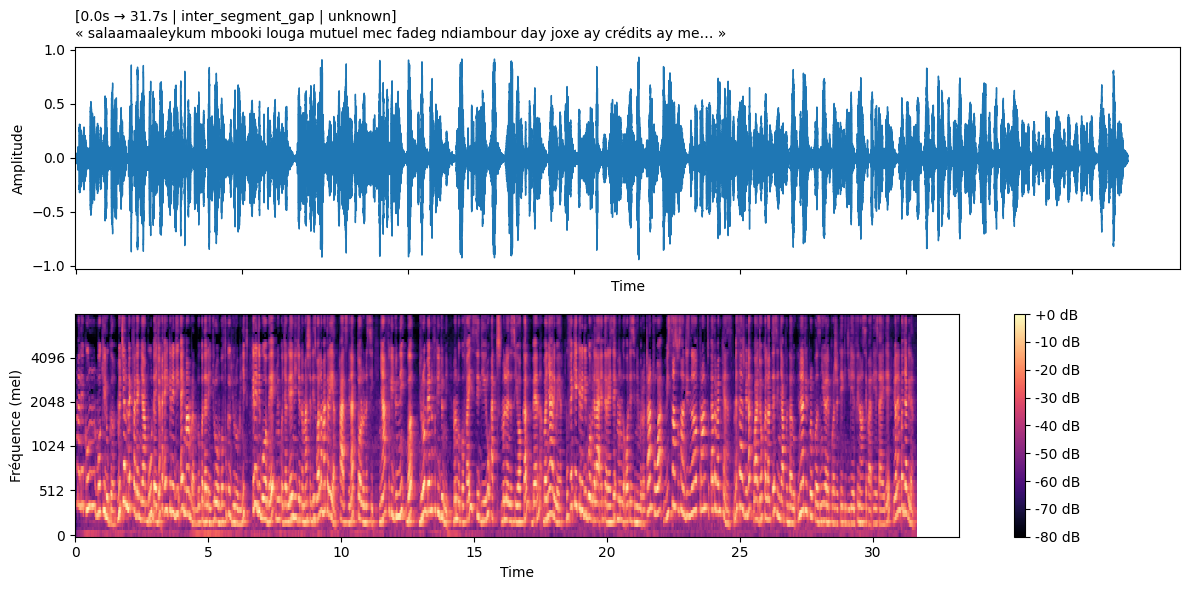

In [21]:
seg = segments[0]
clip = extract_segment(audio, sr, seg["start"], seg["end"])

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# --- Forme d'onde ------------------------------------------------------
librosa.display.waveshow(clip, sr=sr, ax=axes[0])

titre = clean_text_for_wer(seg["text"])[:80]
axes[0].set_title(
    f"[{seg['start']:.1f}s → {seg['end']:.1f}s | {seg['speaker']} | "
    f"{parse_label(seg['label'])['genre']}]\n« {titre}… »",
    loc="left", fontsize=10
)
# Le texte brut fait ~700 caractères sur ce fichier : tronqué à 80,
# et nettoyé pour ne pas afficher les marqueurs %hum / :fra / [r].
axes[0].set_ylabel("Amplitude")

# --- Mel-spectrogramme --------------------------------------------------
S_mel = librosa.feature.melspectrogram(y=clip, sr=sr, n_mels=80)
S_db = librosa.power_to_db(S_mel, ref=np.max)

img = librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[1])
fig.colorbar(img, ax=axes[1], format="%+2.0f dB")
# n_mels=80 : ce n'est PAS arbitraire — c'est exactement l'entrée
# qu'attend Whisper (input_features). Tu visualises donc littéralement
# ce que le modèle « voit », pas une représentation décorative.
#
# Échelle mel plutôt que hz : la parole vit entre 100 Hz et 4 kHz.
# Une échelle linéaire donnerait autant de place aux 6-8 kHz (vides)
# qu'aux basses fréquences (denses en information phonétique).
axes[1].set_ylabel("Fréquence (mel)")

plt.tight_layout()
plt.show()

In [22]:
# --- Écoute -------------------------------------------------------------
display(Audio(clip, rate=sr))
print("Référence nettoyée :", clean_text_for_wer(seg["text"]))

Référence nettoyée : salaamaaleykum mbooki louga mutuel mec fadeg ndiambour day joxe ay crédits ay membres am lu ko dalee juróom ba fukk ak juróom i nit crédit boobee ñu ngi ko jaagleel ñiy jënd marchandise wala matériels xaalis bi nag toll na si ñaar fukki junni ba juróom benn fukki junni mën nga ko fay si diiru at mën nañu la si yokkal benn ba ñaari weer bu fekkee crédit boobu da laa interessé mën nga oote si numéro 33 879 30 95 message bi nag waa jokalante si njàppandalu united purpose ñi yore projet tekki jigéen financé par usaid ñoo leen ko jagleel


In [23]:
from transformers import Wav2Vec2ForCTC, AutoProcessor
import torch

processor = AutoProcessor.from_pretrained("facebook/mms-1b-all")
model = Wav2Vec2ForCTC.from_pretrained("facebook/mms-1b-all")

# Bascule sur l'adaptateur wolof
processor.tokenizer.set_target_lang("wol")
model.load_adapter("wol")

Loading weights: 100%|██████████| 1096/1096 [00:00<00:00, 1691.93it/s]


In [24]:
def transcrire(clip, sr=16000):
    inputs = processor(clip, sampling_rate=sr, return_tensors="pt")
    with torch.no_grad():
        logits = model(**inputs).logits
    ids = torch.argmax(logits, dim=-1)[0]
    return processor.decode(ids)

In [25]:
print("segments             :", len(segments))
print("non vides            :", sum(1 for s in segments if clean_text_for_wer(s["text"]).strip()))
print("hors pseudo-locuteurs:", sum(1 for s in segments if s["speaker"] not in PSEUDO_LOCUTEURS))
print("durée >= 0.5s        :", sum(1 for s in segments if s["end"] - s["start"] >= 0.5))
print("locuteurs présents   :", Counter(s["speaker"] for s in segments).most_common())

segments             : 1
non vides            : 1


NameError: name 'PSEUDO_LOCUTEURS' is not defined

In [27]:
import random, time
import jiwer
from tqdm import tqdm    # au lieu de tqdm.notebook


PSEUDO_LOCUTEURS = {"excluded_region", "inter_segment_gap"}

utiles = [s for s in segments
          if clean_text_for_wer(s["text"]).strip()      # ← le vrai critère
          and (s["end"] - s["start"]) >= 0.5]

# --- 1. ÉCHANTILLONNER --------------------------------------------------
# 700 segments × ~10 s = 2 h. Un échantillon de 50 suffit pour un ordre
# de grandeur de WER. Le seed rend le tirage reproductible.
random.seed(42)
echantillon = random.sample(utiles, min(50, len(utiles)))
print(f"{len(echantillon)} segments échantillonnés sur {len(utiles)}")

# --- 2. CHRONOMÉTRER D'ABORD --------------------------------------------
t0 = time.time()
_ = transcrire(extract_segment(audio, sr, echantillon[0]["start"],
                               echantillon[0]["end"]), sr)
dt = time.time() - t0
print(f"~{dt:.1f}s/segment → {dt * len(echantillon) / 60:.0f} min estimées")

# --- 3. BOUCLE AVEC PROGRESSION -----------------------------------------
refs, hyps = [], []
for s in tqdm(echantillon):
    clip = extract_segment(audio, sr, s["start"], s["end"])
    refs.append(clean_text_for_wer(s["text"]))
    hyps.append(clean_text_for_wer(transcrire(clip, sr)))

print(f"\nWER global (n={len(refs)}) : {jiwer.wer(refs, hyps):.1%}")

1 segments échantillonnés sur 1
~93.2s/segment → 2 min estimées


100%|██████████| 1/1 [01:42<00:00, 102.52s/it]



WER global (n=1) : 61.8%


In [29]:
for s in echantillon[:3]:
    clip = extract_segment(audio, sr, s["start"], s["end"])
    print("REF :", clean_text_for_wer(s["text"]))
    print("HYP :", clean_text_for_wer(transcrire(clip, sr)), "\n")

REF : salaamaaleykum mbooki louga mutuel mec fadeg ndiambour day joxe ay crédits ay membres am lu ko dalee juróom ba fukk ak juróom i nit crédit boobee ñu ngi ko jaagleel ñiy jënd marchandise wala matériels xaalis bi nag toll na si ñaar fukki junni ba juróom benn fukki junni mën nga ko fay si diiru at mën nañu la si yokkal benn ba ñaari weer bu fekkee crédit boobu da laa interessé mën nga oote si numéro 33 879 30 95 message bi nag waa jokalante si njàppandalu united purpose ñi yore projet tekki jigéen financé par usaid ñoo leen ko jagleel
HYP : malekum mbokiluga muthel mkfedek njambu day joxe ay kredi ay mamram lu ko dalee juróom ba f5róomi nit kredi boobe ñu ko jagleen ñi jënn marshandis wala materieel haaris bi nak toll na ci 2ba600 mën nga ko fay cidiiru act mën lan la ci yokkal benn ba ñaari weer bu fekkee kredi boobe dala interese mën nga oode ci numero3869395 mesage bi nak waa jokkalante ci njàpp dalu itive popese ñi yore projet tekki jigéen financai par esid ñooleen ko jagleen 
